## Parser

In [1]:
# import sys
# sys.path.append("../")
import numpy as np
import pandas as pd

from frony_document_processor.parser import ParserTXT
from frony_document_processor.parser import ParserPDF
from frony_document_processor.parser import ParserPPTX
from frony_document_processor.parser import ParserPDFImage
from frony_document_processor.parser import ParserImage
from frony_document_processor.parser import ParserDOCX

In [2]:
parser = ParserTXT()
df = parser.parse("test_files/test_txt.txt")
df

,page_number,page_content
0,1,The dominant sequence transduction models are ...


In [3]:
parser = ParserPDF()
df = parser.parse("test_files/test_pdf.pdf")
df

,page_number,page_content
0,1,"Provided proper attribution is provided, Googl..."
1,2,"1 Introduction\nRecurrent neural networks, lon..."
2,3,Figure 1: The Transformer - model architecture...
3,4,Scaled Dot-Product Attention Multi-Head Attent...
4,5,output values. These are concatenated and once...
5,6,"Table 1: Maximum path lengths, per-layer compl..."
6,7,n\nlength is smaller than the representation d...
7,8,Table 2: The Transformer achieves better BLEU ...
8,9,Table 3: Variations on the Transformer archite...
9,10,Table 4: The Transformer generalizes well to E...


In [4]:
print(df.iloc[-6]["page_content"])

Table 4: The Transformer generalizes well to English constituency parsing (Results are on Section 23
of WSJ)
Parser Training WSJ 23 F1
<표>
|    | Parser                         | Training               | WSJ23F1   |
|---:|:-------------------------------|:-----------------------|:----------|
|  0 | Vinyals&Kaiserelal. (2014)[37] | WSJonly,discriminative | 88.3      |
|    | Petrovetal. (2006)[29]         | WSJonly,discriminative | 90.4      |
|    | Zhuetal. (2013)[40]            | WSJonly,discriminative | 90.4      |
|    | Dyeretal. (2016)[8]            | WSJonly,discriminative | 91.7      |
|  1 | Transformer(4layers)           | WSJonly,discriminative | 91.3      |
|  2 | Zhuetal. (2013)[40]            | semi-supervised        | 91.3      |
|    | Huang&Harper(2009)[14]         | semi-supervised        | 91.3      |
|    | McCloskyetal. (2006)[26]       | semi-supervised        | 92.1      |
|    | Vinyals&Kaiserelal. (2014)[37] | semi-supervised        | 92.1      |
|  3 | Transfo

In [5]:
parser = ParserPPTX()
df = parser.parse("test_files/test_pptx.pptx")
df

complete conversion from PPTX to PDF / output_path=./.cache/parser-pptx/685c145ad2a94e78b58edf4c0978afd8.pdf


,page_number,page_content
0,1,iVBORw0KGgoAAAANSUhEUgAAD6EAAAjKCAIAAADiFw3ZAA...
1,2,iVBORw0KGgoAAAANSUhEUgAAD6EAAAjKCAIAAADiFw3ZAA...
2,3,iVBORw0KGgoAAAANSUhEUgAAD6EAAAjKCAIAAADiFw3ZAA...


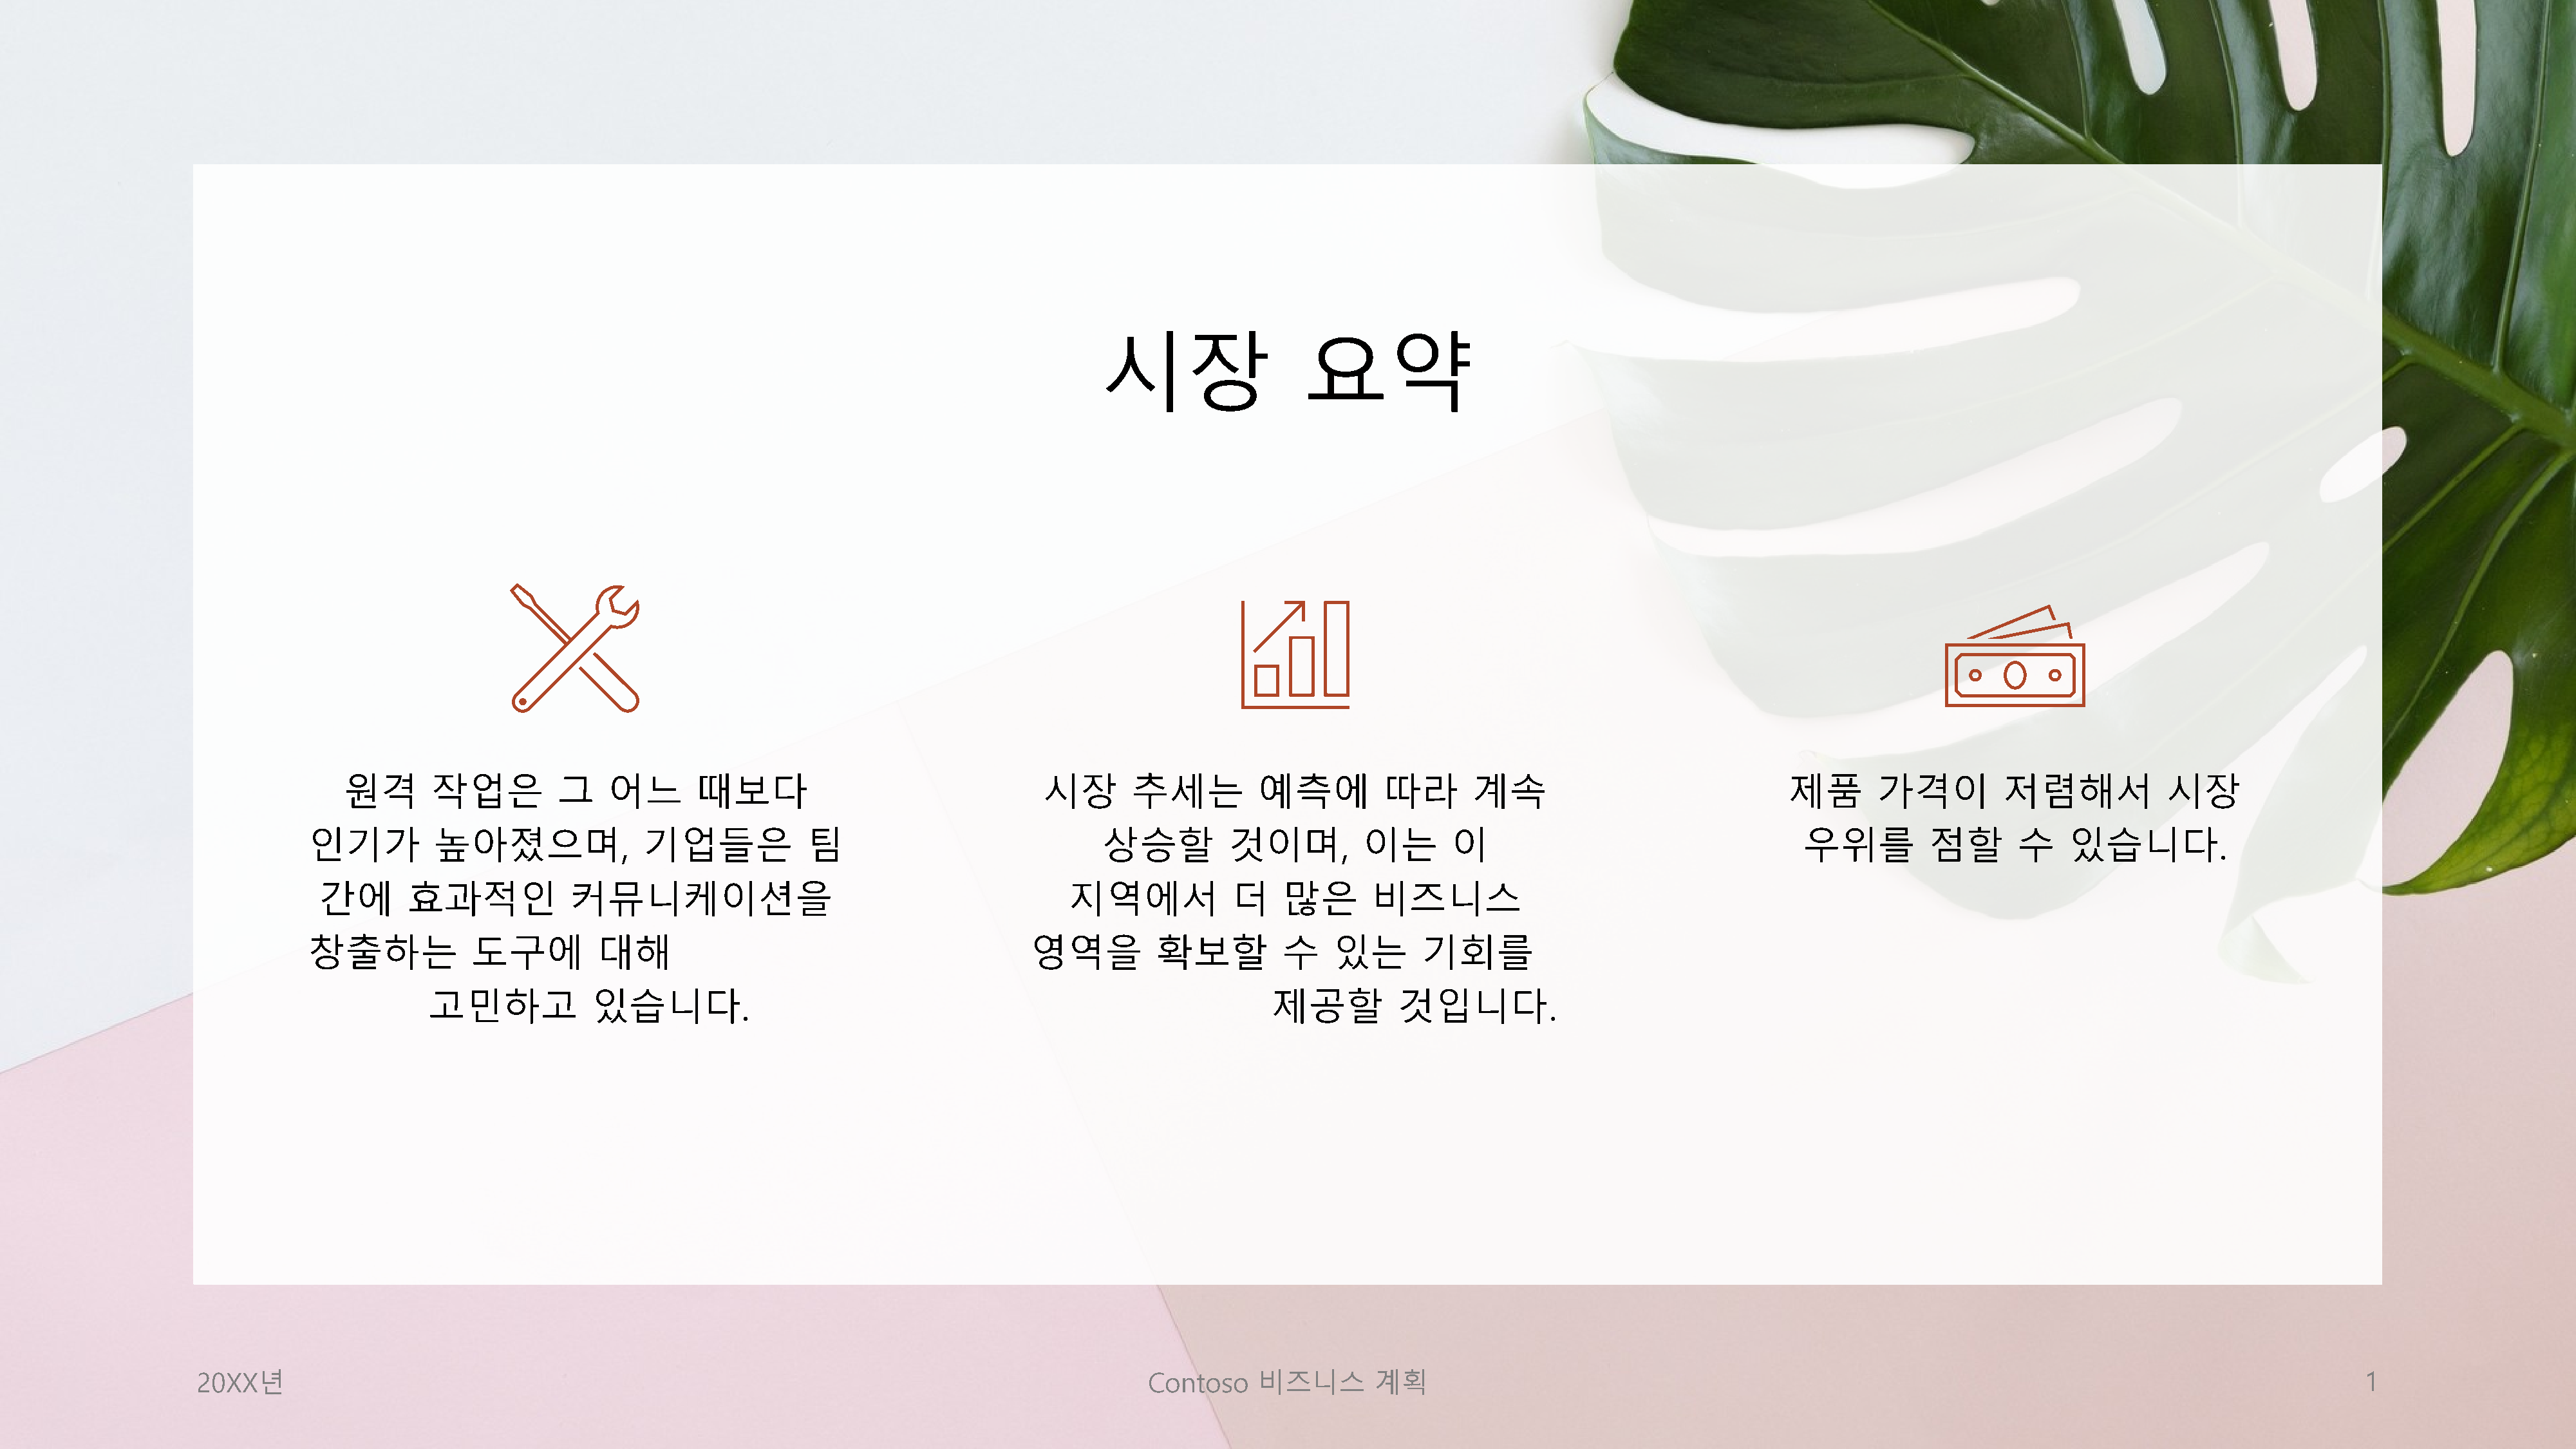

In [6]:
import base64
from PIL import Image
import io
# 바이트 스트림을 이미지로 변환
image = Image.open(io.BytesIO(base64.b64decode(df["page_content"].iloc[0])))
# 이미지 표시
image

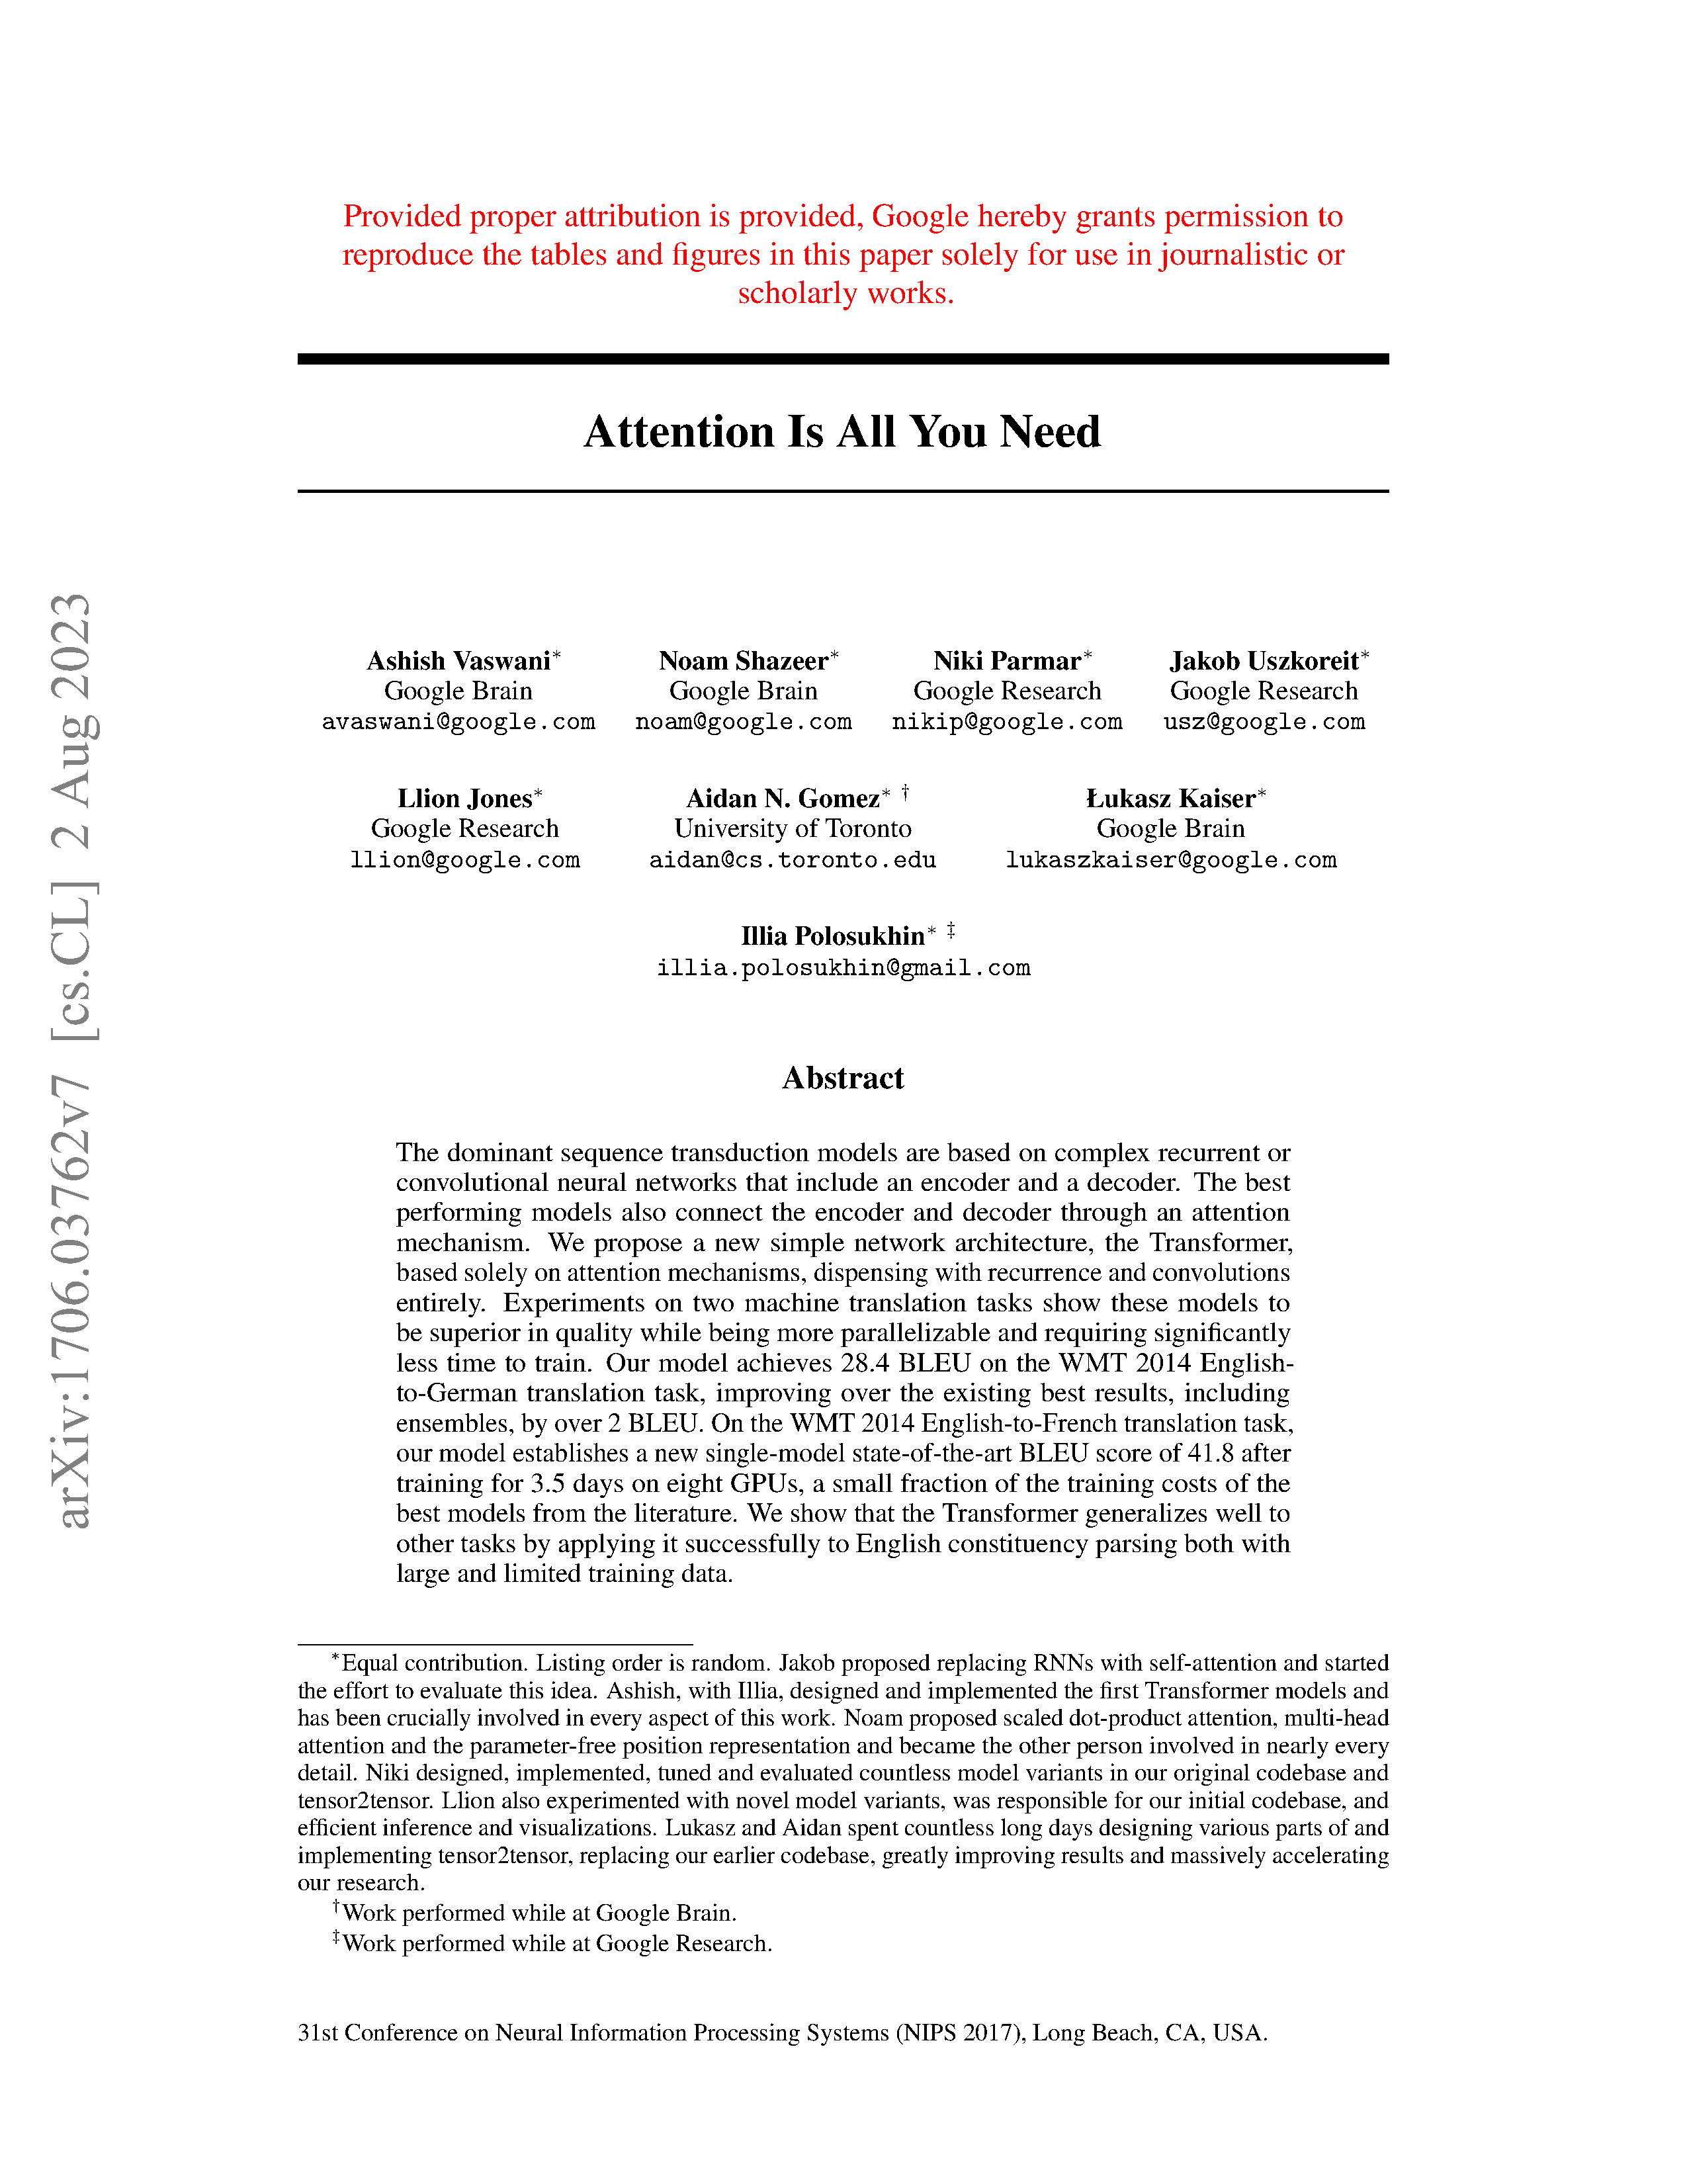

In [7]:
parser = ParserPDFImage()
df = parser.parse("test_files/test_pdf.pdf")
df
import base64
from PIL import Image
import io
# 바이트 스트림을 이미지로 변환
image = Image.open(io.BytesIO(base64.b64decode(df["page_content"].iloc[0])))
# 이미지 표시
image

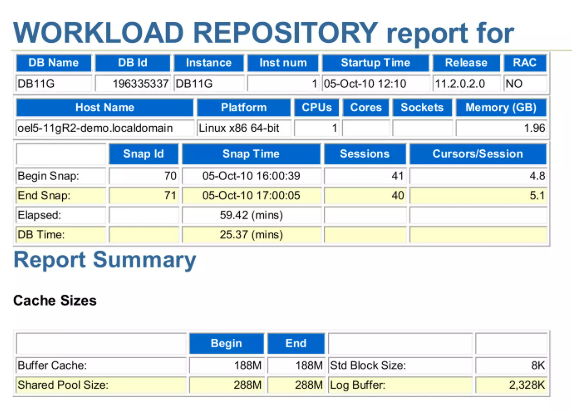

In [8]:
parser = ParserImage()
df = parser.parse("test_files/test_img.png")
df
import base64
from PIL import Image
import io
# 바이트 스트림을 이미지로 변환
image = Image.open(io.BytesIO(base64.b64decode(df["page_content"].iloc[0])))
# 이미지 표시
image

In [14]:
len(doc.tables)

0

In [13]:
doc.paragraphs[1:3]

In [7]:
from docx import Document
# open document
doc = Document("test_files/test_docx.docx")
# prepare page container
page_container = []
content = ""
# traverse all elements in document
for element in doc.element.body:
    print(element.tag)

{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p
{http://schemas.openxmlformats.org/wordp

In [18]:
import io

class ParserDOCX():
    def __init__(self):
        pass
    
    def parse(self, file: io.BytesIO | str):
        try:
            # open document
            doc = Document(file)
            paragraphs = iter(doc.paragraphs)
            tables = iter(doc.tables)
            # prepare page container
            page_container = []
            # traverse all elements in document
            for element in doc.element.body:
                # handle paragraph element
                if element.tag.endswith('p'):
                    para = next(paragraphs)
                    content = para.text.strip()
                    if content:
                        page_container.append({
                            'page_number': len(page_container) + 1,
                            'page_content': content
                        })
                # handle table element
                elif element.tag.endswith('tbl'):
                    table = next(tables)
                    table_content = []
                    for row in table.rows:
                        row_content = []
                        for cell in row.cells:
                            cell_text = ""
                            for para in cell.paragraphs:
                                cell_text += para.text + " "
                            row_content.append(cell_text.strip())
                        table_content.append(row_content)
                    # convert table to markdown
                    if table_content:
                        content = ""
                        # header row
                        content += "\n|" + "|".join(table_content[0]) + "|\n"
                        # separator
                        content += "|" + "|".join(["---"] * len(table_content[0])) + "|\n"
                        # data row
                        for row in table_content[1:]:
                            content += "|" + "|".join(row) + "|"
                        page_container.append({
                            'page_number': len(page_container) + 1,
                            'page_content': content
                        })
                # handle section break
                else:
                    continue
            return pd.DataFrame(page_container)
        except Exception as e:
            print(f"error in parsing DOCX -> {e}")
            return None


In [19]:
parser = ParserDOCX()
df = parser.parse("test_files/test_docx.docx")
df

,page_number,page_content
0,1,제 3 회 감시 ∙정찰 ∙정보 학술대회
1,2,논문작성지침
2,3,1. 홈페이지에서 양식을 다운 받아 작성하여 제출바랍니다.
3,4,"2. 4페이지 이하 2칼럼의 형태로 한글파일, 또는 워드파일로 형태로 작성하시기 바..."
4,5,PDF파일로도 변환하시어 2개의 파일을 제출하시기 바랍니다.
...,...,...
71,72,"신호취득회로에 있어서는 20×4 TDI용 신호취득회로의 동작을 확인하였으며, 새로운..."
72,73,참고문헌
73,74,"[1] W. E. Tennant, C. A. Cockrum, J. B. Gilpin..."
74,75,"[2] Y.-H. Kim, T.S. Kim D.A. Redfern, C.A.Musc..."


In [20]:
print(df["page_content"].iloc[0])

제 3 회 감시 ∙정찰 ∙정보 학술대회
